In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
import joblib

# 1. Load and clean data
df = pd.read_csv('../datasets/SEER Breast Cancer Dataset .csv')

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace(',', '')

# Handle missing values
df.replace('', pd.NA, inplace=True)
df.dropna(how='all', inplace=True)

# 2. Separate features and target
X = df.drop(['Status', 'Survival_Months'], axis=1)
y = df['Status']

# Store metadata
feature_names = X.columns.tolist()
class_names = y.unique().tolist()  # ['Alive', 'Dead']

print("Feature names:", feature_names)
print("Class names:", class_names)

# 3. Preprocess numerical features
numeric_features = ['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Regional_Node_Positive']
numeric_imputer = SimpleImputer(strategy='median')
X[numeric_features] = numeric_imputer.fit_transform(X[numeric_features])

scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# 4. Preprocess categorical features
categorical_features = ['Race', 'Marital_Status', 'T_Stage', 'N_Stage', '6th_Stage', 
                       'Grade', 'A_Stage', 'Estrogen_Status', 'Progesterone_Status']
categorical_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
X[categorical_features] = categorical_imputer.fit_transform(X[categorical_features])

# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cats = encoder.fit_transform(X[categorical_features])
encoded_cat_names = encoder.get_feature_names_out(categorical_features)

# Combine features
X_processed = pd.concat([
    pd.DataFrame(X[numeric_features]),
    pd.DataFrame(encoded_cats, columns=encoded_cat_names)
], axis=1)

# 5. Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.3, random_state=42
)

# 7. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 8. Evaluate
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

# 9. Save artifacts
artifacts = {
    'model': rf,
    'numeric_imputer': numeric_imputer,
    'categorical_imputer': categorical_imputer,
    'scaler': scaler,
    'encoder': encoder,
    'label_encoder': label_encoder,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'class_names': class_names
}

joblib.dump(artifacts, 'cancer_model_no_pipeline.joblib')

# 10. Example prediction
loaded = joblib.load('cancer_model_no_pipeline.joblib')



Feature names: ['Age', 'Race', 'Marital_Status', 'Unnamed:_3', 'T_Stage', 'N_Stage', '6th_Stage', 'Grade', 'A_Stage', 'Tumor_Size', 'Estrogen_Status', 'Progesterone_Status', 'Regional_Node_Examined', 'Regional_Node_Positive']
Class names: ['Alive', 'Dead']
F1 Score: 0.7945


In [2]:
class_names

['Alive', 'Dead']

In [3]:
feature_names = X_train.columns

In [4]:
import sys
sys.path.append("../")

/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, bu


Explaining for class: Alive


Sampling hypothesis space: 100%|██████████| 10/10 [00:00<00:00, 21.50it/s]


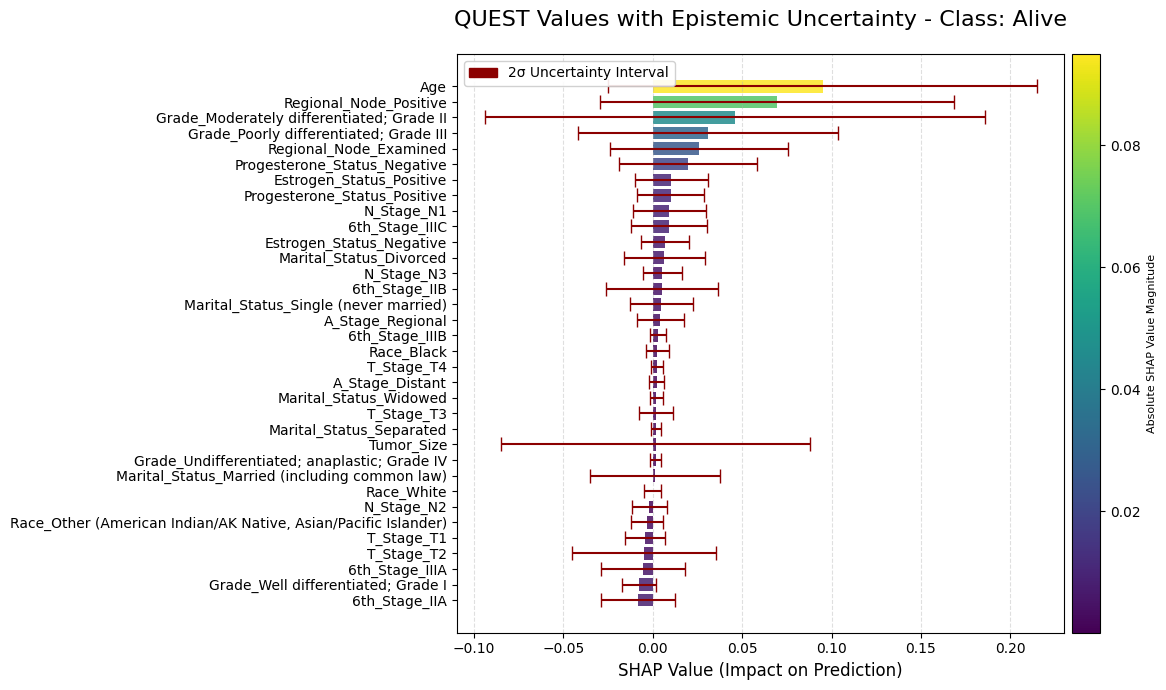

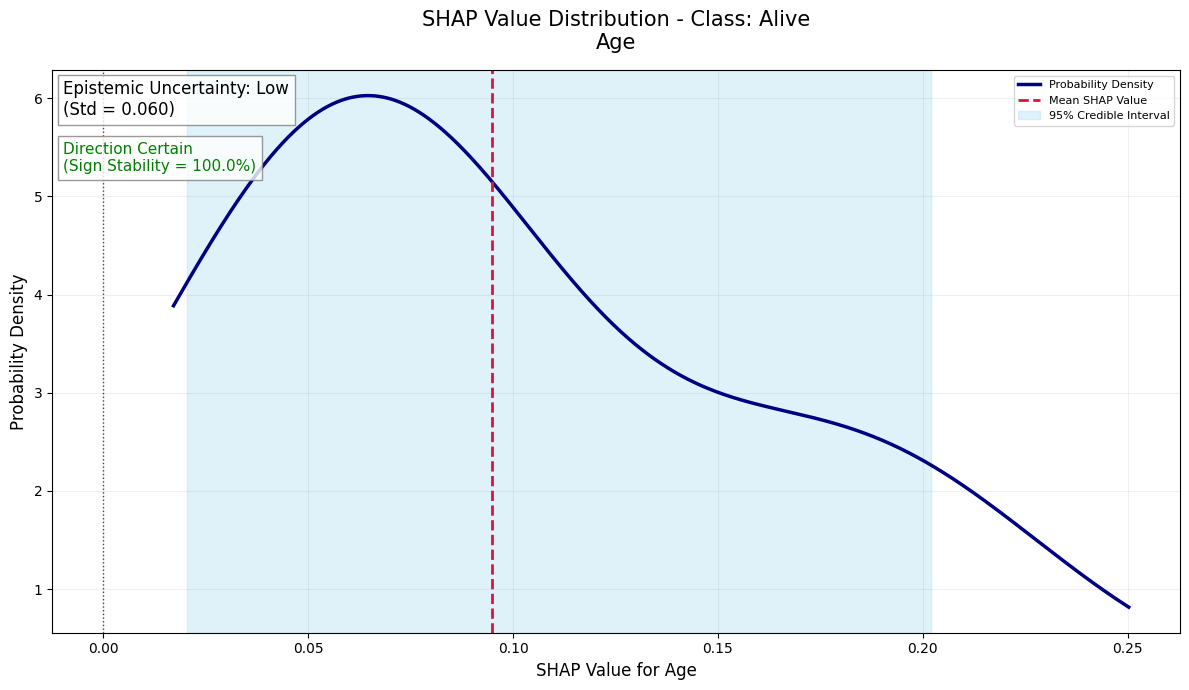

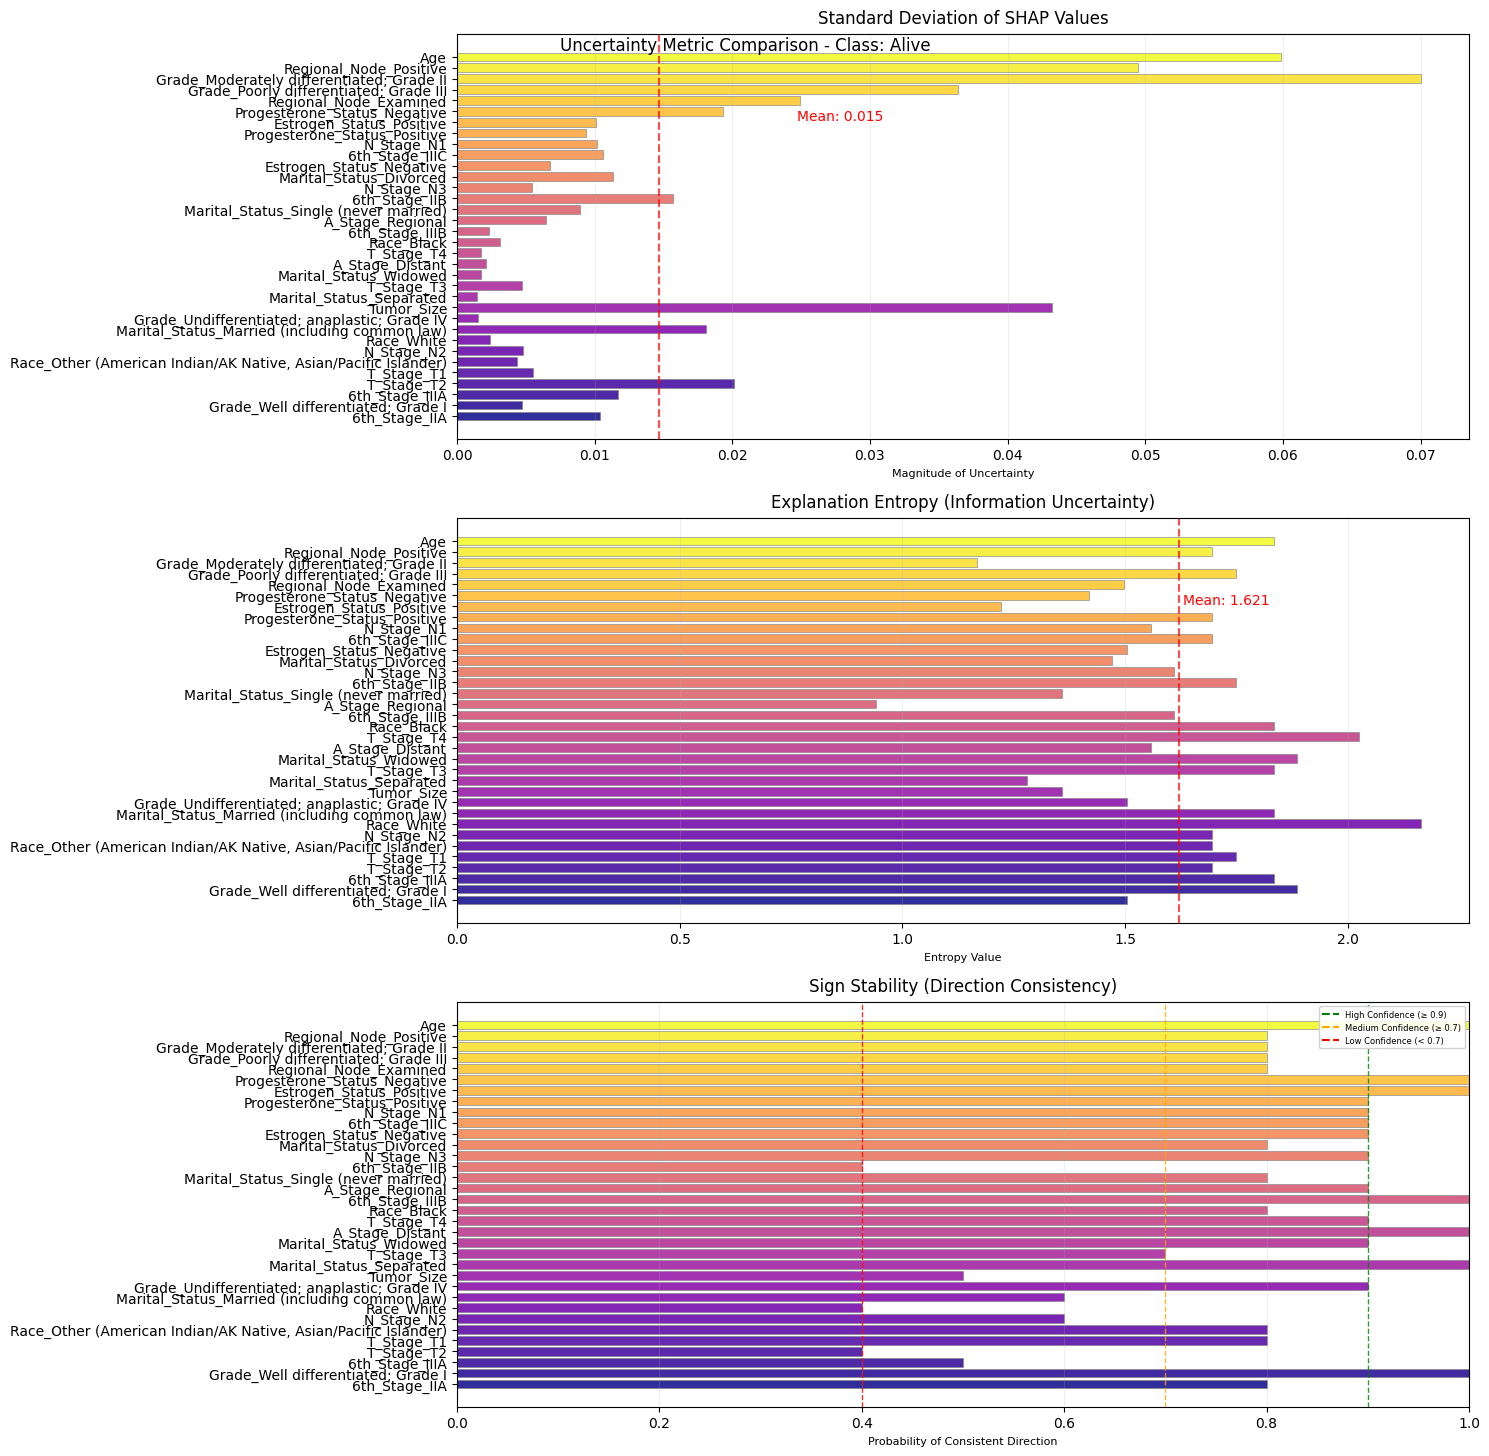


Explaining for class: Dead


Sampling hypothesis space: 100%|██████████| 10/10 [00:00<00:00, 21.35it/s]


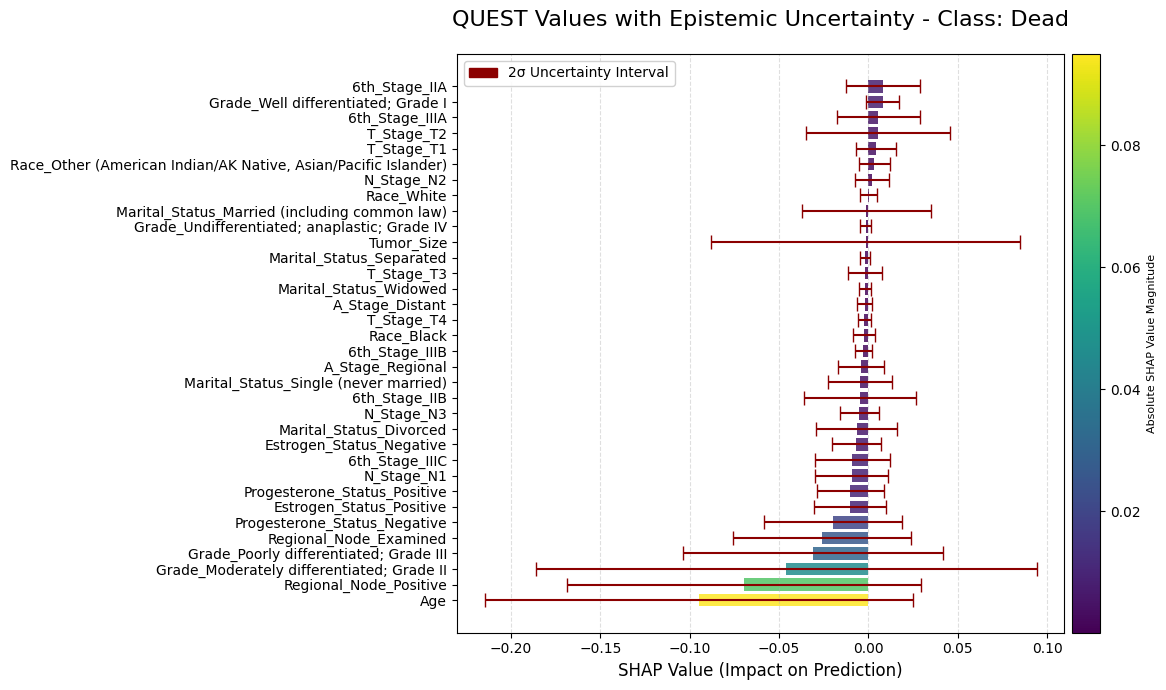

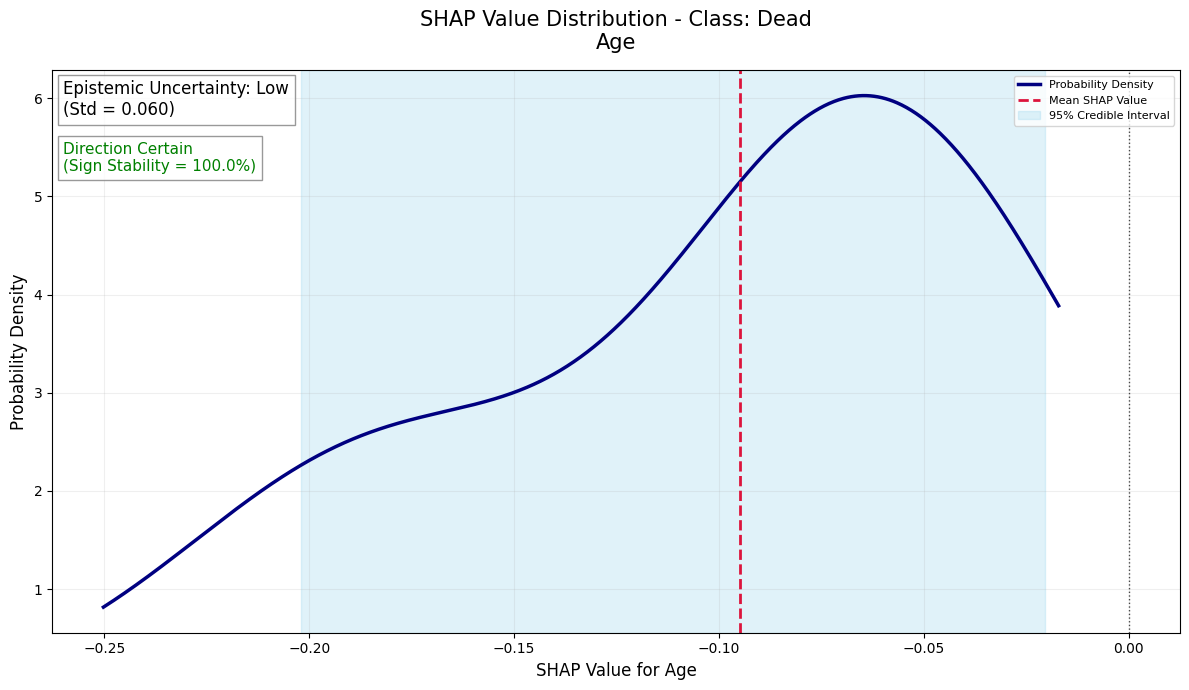

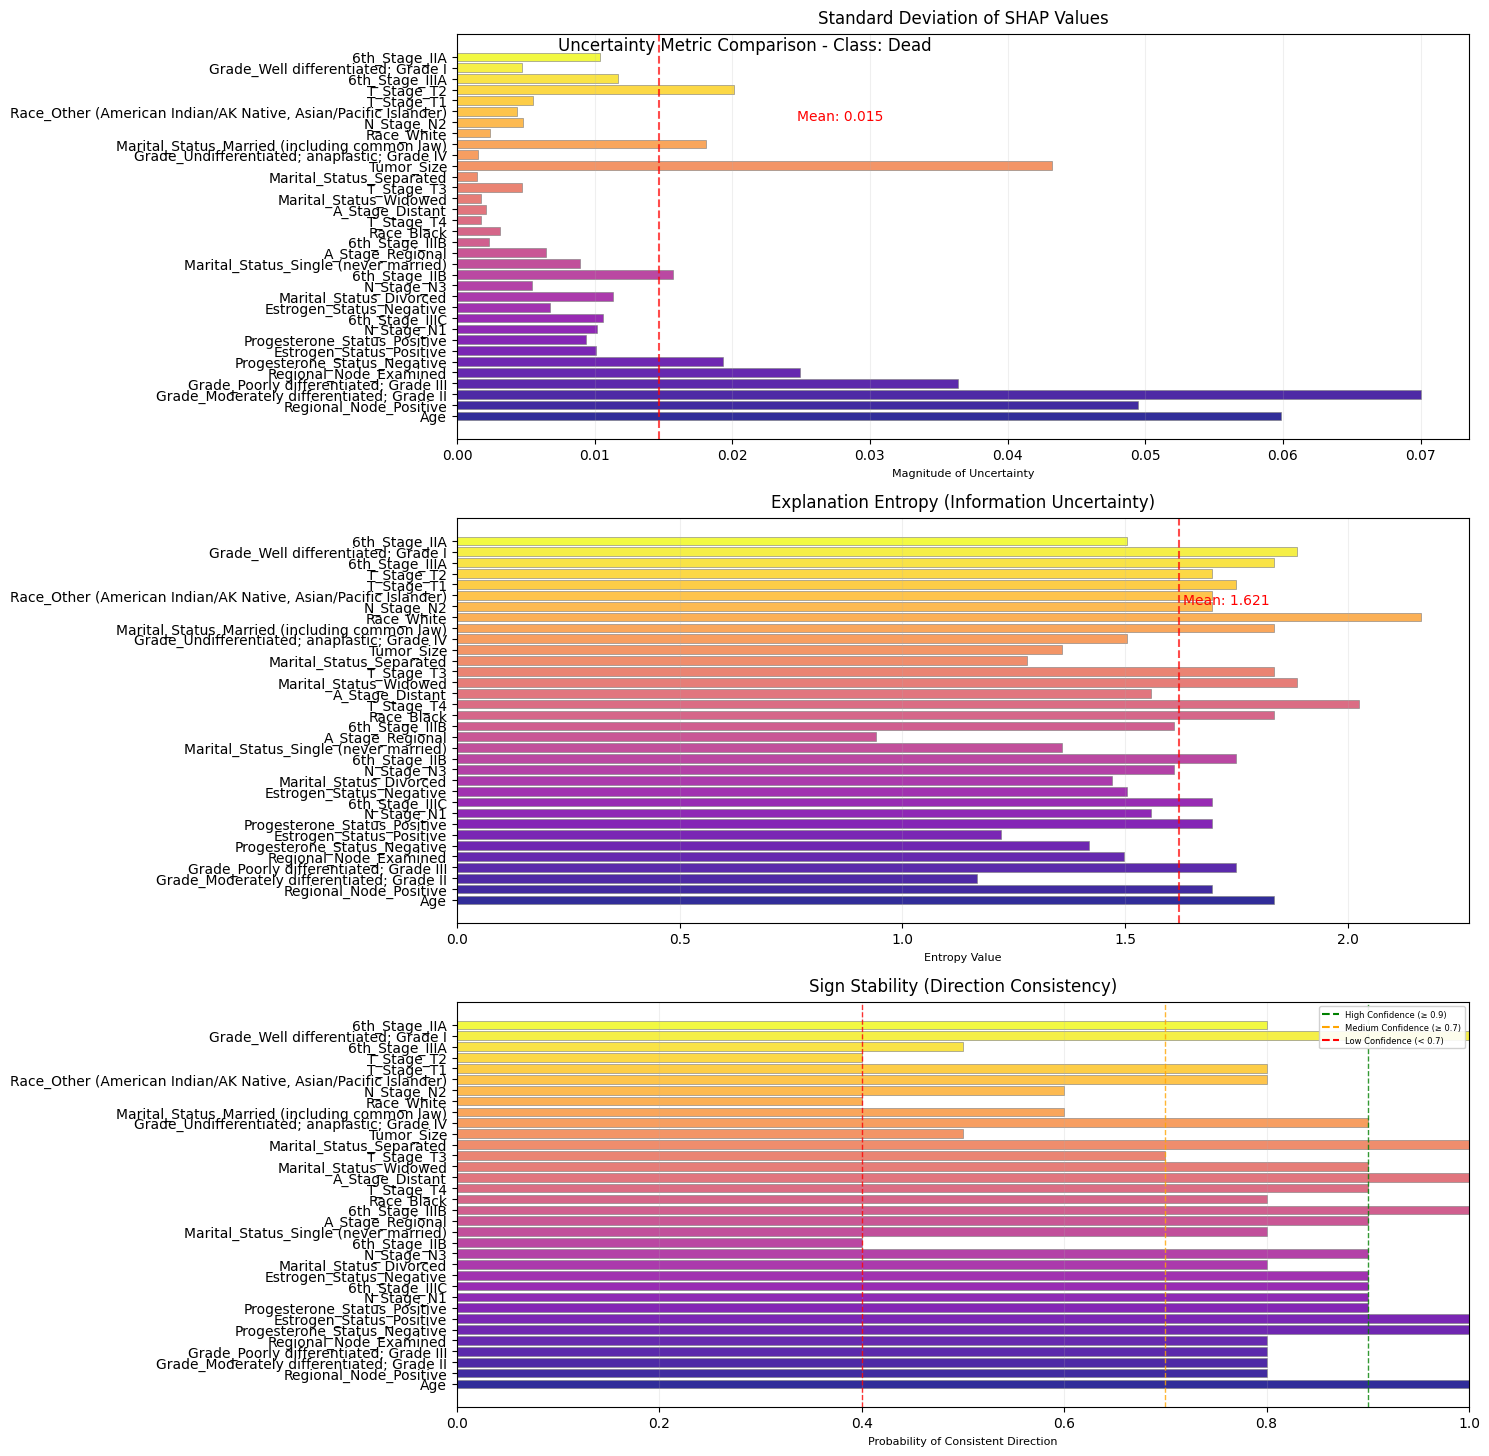

In [5]:
from QUEST import QUESTExplainerClassification

import numpy as np
model = rf

explainer = QUESTExplainerClassification(model, X_train, y_train, beta=3.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, n_samples=10, class_idx=class_idx, alpha=0.6)
       # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    most_important_feature = np.argmax(np.abs(results['mean']))
    explainer.plot_uncertainty_distribution(
        results,
        feature_names,
        most_important_feature,
        class_name=class_name
    )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
